In [5]:
"""
YOLOv1 (backbone ResNet34) - PIPELINE ĐÃ SỬA:
  - Dataset đọc PASCAL VOC THẬT (tự tải qua torchvision, parse XML annotation)
  - Train trên dữ liệu thật
  - Test: vừa tính loss vừa tính mAP@0.5 (đúng chỉ số cho object detection)
  - Inference thật: decode grid 7x7x30 -> box + áp NMS + ngưỡng confidence
  - Lưu checkpoint sau khi train
Chạy: python yolov1_resnet_voc_fixed.py
"""
import os
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms.functional as TF
from torchvision.datasets import VOCDetection

# ==========================================
# 0. LỚP ĐỐI TƯỢNG PASCAL VOC
# ==========================================
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(VOC_CLASSES)}

# ==========================================
# 1. KIẾN TRÚC MẠNG YOLOv1 (giữ nguyên ý tưởng backbone ResNet34)
# ==========================================
class YOLOv1(nn.Module):
    def __init__(self, split_size=7, num_boxes=2, num_classes=20):
        super(YOLOv1, self).__init__()
        self.S, self.B, self.C = split_size, num_boxes, num_classes

        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        # bỏ avgpool + fc -> với input 448x448, output (N, 512, 14, 14)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 14 * 14, 4096),
            nn.Dropout(0.5),      # đổi thứ tự Dropout trước LeakyReLU cho đúng paper gốc
            nn.LeakyReLU(0.1),
            nn.Linear(4096, self.S * self.S * (self.C + self.B * 5)),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x.view(-1, self.S, self.S, self.C + self.B * 5)


# ==========================================
# 2. HÀM IOU VÀ YOLO LOSS (giữ nguyên - đã đúng)
# ==========================================
def calculate_iou(boxes_preds, boxes_labels):
    box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
    box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
    box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
    box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2

    box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
    box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
    box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
    box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))
    return intersection / (box1_area + box2_area - intersection + 1e-6)


class YoloLoss(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YoloLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S, self.B, self.C = S, B, C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5.0

    def forward(self, predictions, target):
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)

        iou_b1 = calculate_iou(predictions[..., 21:25], target[..., 21:25])
        iou_b2 = calculate_iou(predictions[..., 26:30], target[..., 21:25])
        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)

        _, bestbox = torch.max(ious, dim=0)
        exists_box = target[..., 20].unsqueeze(3)

        box_preds = exists_box * (bestbox * predictions[..., 26:30] + (1 - bestbox) * predictions[..., 21:25])
        box_targets = exists_box * target[..., 21:25]
        box_preds[..., 2:4] = torch.sign(box_preds[..., 2:4]) * torch.sqrt(torch.abs(box_preds[..., 2:4] + 1e-6))
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])
        box_loss = self.mse(box_preds, box_targets)

        pred_box = (bestbox * predictions[..., 25:26] + (1 - bestbox) * predictions[..., 20:21])
        object_loss = self.mse(exists_box * pred_box, exists_box * target[..., 20:21])

        no_object_loss = self.mse((1 - exists_box) * predictions[..., 20:21], (1 - exists_box) * target[..., 20:21])
        no_object_loss += self.mse((1 - exists_box) * predictions[..., 25:26], (1 - exists_box) * target[..., 20:21])

        class_loss = self.mse(exists_box * predictions[..., :20], exists_box * target[..., :20])

        return (self.lambda_coord * box_loss) + object_loss + (self.lambda_noobj * no_object_loss) + class_loss


# ==========================================
# 3. QUẢN LÝ DỮ LIỆU (ĐÃ SỬA: đọc PASCAL VOC thật)
# ==========================================
class VOCDataset(torch.utils.data.Dataset):
    """
    Bọc quanh torchvision.datasets.VOCDetection: tự tải VOC (nếu download=True),
    đọc ảnh + parse XML annotation thật, resize, và mã hoá thành target lưới 7x7x30.
    """

    def __init__(self, root, year="2007", image_set="trainval", S=7, B=2, C=20,
                 img_size=448, download=True):
        self.voc = VOCDetection(root=root, year=year, image_set=image_set, download=download)
        self.S, self.B, self.C = S, B, C
        self.img_size = img_size

    def __len__(self):
        return len(self.voc)

    @staticmethod
    def _parse_annotation(annotation, img_w, img_h):
        boxes = []
        objects = annotation["annotation"]["object"]
        if isinstance(objects, dict):  # chỉ 1 object -> torchvision không bọc list
            objects = [objects]

        for obj in objects:
            name = obj["name"]
            if name not in CLASS_TO_IDX:
                continue
            bnd = obj["bndbox"]
            xmin, ymin = float(bnd["xmin"]), float(bnd["ymin"])
            xmax, ymax = float(bnd["xmax"]), float(bnd["ymax"])

            x_center = ((xmin + xmax) / 2) / img_w
            y_center = ((ymin + ymax) / 2) / img_h
            w = (xmax - xmin) / img_w
            h = (ymax - ymin) / img_h
            boxes.append([CLASS_TO_IDX[name], x_center, y_center, w, h])
        return boxes

    def __getitem__(self, idx):
        img, annotation = self.voc[idx]
        img_w, img_h = img.size
        boxes = self._parse_annotation(annotation, img_w, img_h)

        img = img.resize((self.img_size, self.img_size))
        img = TF.to_tensor(img)  # chuẩn hoá 0..1, shape (3, img_size, img_size)

        target = torch.zeros((self.S, self.S, self.C + self.B * 5))
        for class_label, x, y, w, h in boxes:
            class_label = int(class_label)
            i, j = int(self.S * y), int(self.S * x)
            i, j = min(i, self.S - 1), min(j, self.S - 1)

            x_cell, y_cell = self.S * x - j, self.S * y - i
            w_cell, h_cell = w * self.S, h * self.S

            if target[i, j, 20] == 0:  # mỗi ô chỉ nhận 1 object (chuẩn YOLOv1)
                target[i, j, 20] = 1
                target[i, j, 21:25] = torch.tensor([x_cell, y_cell, w_cell, h_cell])
                target[i, j, class_label] = 1

        return img, target


# ==========================================
# 4. HẬU XỬ LÝ: DECODE GRID -> BOX THẬT + NMS + mAP  (MỚI - trước đây chưa có)
# ==========================================
def decode_predictions(predictions, S=7, C=20, B=2):
    """(N,S,S,30) -> (N, S*S, 6) = [class, conf, x, y, w, h] theo toạ độ toàn ảnh 0..1."""
    predictions = predictions.detach().to("cpu")
    batch_size = predictions.shape[0]

    bboxes1 = predictions[..., 21:25]
    bboxes2 = predictions[..., 26:30]
    scores = torch.cat((predictions[..., 20:21].unsqueeze(0), predictions[..., 25:26].unsqueeze(0)), dim=0)
    best_box = scores.argmax(0)
    best_boxes = bboxes1 * (1 - best_box) + bboxes2 * best_box

    cell_indices = torch.arange(S).repeat(batch_size, S, 1).unsqueeze(-1)
    x = 1 / S * (best_boxes[..., 0:1] + cell_indices)
    y = 1 / S * (best_boxes[..., 1:2] + cell_indices.permute(0, 2, 1, 3))
    wh = 1 / S * best_boxes[..., 2:4]

    converted = torch.cat((x, y, wh), dim=-1)
    pred_class = predictions[..., :C].argmax(-1).unsqueeze(-1)
    best_conf = torch.max(predictions[..., 20:21], predictions[..., 25:26])
    out = torch.cat((pred_class, best_conf, converted), dim=-1)
    return out.reshape(batch_size, S * S, 6)


def non_max_suppression(bboxes, iou_threshold=0.5, conf_threshold=0.4):
    """bboxes: list [class, conf, x, y, w, h]."""
    bboxes = [b for b in bboxes if b[1] > conf_threshold]
    bboxes = sorted(bboxes, key=lambda b: b[1], reverse=True)
    kept = []
    while bboxes:
        chosen = bboxes.pop(0)
        bboxes = [
            b for b in bboxes
            if b[0] != chosen[0]
            or calculate_iou(torch.tensor(chosen[2:]), torch.tensor(b[2:])).item() < iou_threshold
        ]
        kept.append(chosen)
    return kept


def mean_average_precision(pred_boxes, true_boxes, iou_threshold=0.5, num_classes=20):
    """pred_boxes/true_boxes: list [img_idx, class, conf, x, y, w, h]."""
    average_precisions = []
    epsilon = 1e-6

    for c in range(num_classes):
        detections = [d for d in pred_boxes if d[1] == c]
        ground_truths = [g for g in true_boxes if g[1] == c]

        amount_bboxes = Counter([gt[0] for gt in ground_truths])
        for key, val in amount_bboxes.items():
            amount_bboxes[key] = torch.zeros(val)

        detections.sort(key=lambda x: x[2], reverse=True)
        TP, FP = torch.zeros(len(detections)), torch.zeros(len(detections))
        total_true = len(ground_truths)
        if total_true == 0:
            continue

        for d_idx, det in enumerate(detections):
            gts_same_img = [g for g in ground_truths if g[0] == det[0]]
            best_iou, best_gt_idx = 0, -1
            for gi, gt in enumerate(gts_same_img):
                iou = calculate_iou(torch.tensor(det[3:]), torch.tensor(gt[3:])).item()
                if iou > best_iou:
                    best_iou, best_gt_idx = iou, gi

            if best_iou > iou_threshold and amount_bboxes[det[0]][best_gt_idx] == 0:
                TP[d_idx] = 1
                amount_bboxes[det[0]][best_gt_idx] = 1
            else:
                FP[d_idx] = 1

        TP_c, FP_c = torch.cumsum(TP, 0), torch.cumsum(FP, 0)
        recalls = TP_c / (total_true + epsilon)
        precisions = TP_c / (TP_c + FP_c + epsilon)
        precisions = torch.cat((torch.tensor([1]), precisions))
        recalls = torch.cat((torch.tensor([0]), recalls))
        average_precisions.append(torch.trapz(precisions, recalls))

    return sum(average_precisions) / len(average_precisions) if average_precisions else torch.tensor(0.0)


def get_bboxes_from_loader(loader, model, device, S=7, C=20, B=2, iou_threshold=0.5, conf_threshold=0.4):
    """Chạy model trên cả loader, decode + NMS, trả về list box để tính mAP."""
    model.eval()
    all_pred, all_true = [], []
    idx = 0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            preds_decoded = decode_predictions(preds, S, C, B)
            true_decoded = decode_predictions(targets, S, C, B)  # tái dùng để lấy box thật từ target

            for b in range(images.shape[0]):
                nms_boxes = non_max_suppression(preds_decoded[b].tolist(), iou_threshold, conf_threshold)
                all_pred += [[idx] + box for box in nms_boxes]
                all_true += [[idx] + box for box in true_decoded[b].tolist() if box[1] > conf_threshold]
                idx += 1
    model.train()
    return all_pred, all_true


def save_checkpoint(model, optimizer, epoch, path="checkpoints/yolov1_resnet.pth"):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({"epoch": epoch, "state_dict": model.state_dict(), "optimizer": optimizer.state_dict()}, path)
    print(f"=> Đã lưu checkpoint: {path}")


# ==========================================
# 5. CÁC HÀM XỬ LÝ LÕI (TRAIN, TEST, INFER)
# ==========================================
def train_fn(train_loader, model, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)
        predictions = model(images)
        loss = criterion(predictions, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def test_fn(test_loader, model, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            predictions = model(images)
            loss = criterion(predictions, targets)
            total_loss += loss.item()
    return total_loss / len(test_loader)


def predict_single_image(model, image_tensor, device, conf_threshold=0.4, iou_threshold=0.5):
    """Trả về danh sách box đã decode + NMS: [class_id, conf, x, y, w, h]."""
    model.eval()
    with torch.no_grad():
        predictions = model(image_tensor.unsqueeze(0).to(device))
    boxes = decode_predictions(predictions, model.S, model.C, model.B)[0].tolist()
    boxes = non_max_suppression(boxes, iou_threshold=iou_threshold, conf_threshold=conf_threshold)
    model.train()
    return boxes


# ==========================================
# 6. KHỐI ĐIỀU KHIỂN CHÍNH (MAIN)
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Bắt đầu quy trình YOLOv1 trên thiết bị: {device}")

    # 1. Khởi tạo model / loss / optimizer
    model = YOLOv1().to(device)
    criterion = YoloLoss()
    optimizer = optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.0005)

    # 2. Tải + chuẩn bị dữ liệu PASCAL VOC THẬT
    #    download=True: tự tải VOC2007 (~450MB) vào thư mục "data/" nếu chưa có.
    #    Nếu mạng lỗi (host.robots.ox.ac.uk đôi khi chậm/không ổn định), tải thủ công
    #    rồi đặt download=False, xem hướng dẫn cấu trúc thư mục trong README.
    train_dataset = VOCDataset(root="data", year="2007", image_set="trainval", download=True)
    test_dataset = VOCDataset(root="data", year="2007", image_set="test", download=True)

    BATCH_SIZE = 16
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True
    )
    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
    )

    # 3. Vòng lặp Huấn luyện + Đánh giá
    EPOCHS = 20          # demo; paper gốc train 135 epoch trên VOC07+12 sau khi pretrain ImageNet
    EVAL_EVERY = 5
    for epoch in range(EPOCHS):
        train_loss = train_fn(train_loader, model, optimizer, criterion, device)
        print(f"Epoch [{epoch + 1}/{EPOCHS}] | Train Loss: {train_loss:.4f}")

        if (epoch + 1) % EVAL_EVERY == 0 or epoch == EPOCHS - 1:
            test_loss = test_fn(test_loader, model, criterion, device)
            pred_boxes, true_boxes = get_bboxes_from_loader(test_loader, model, device, S=model.S, C=model.C, B=model.B)
            mAP = mean_average_precision(pred_boxes, true_boxes, iou_threshold=0.5, num_classes=model.C)
            print(f"  -> Test Loss: {test_loss:.4f} | mAP@0.5: {mAP:.4f}")
            save_checkpoint(model, optimizer, epoch + 1)

    # 4. Thực chiến: lấy 1 ảnh THẬT từ tập test (không phải nhiễu ngẫu nhiên)
    print("\n--- Bắt đầu giai đoạn Thực chiến (Inference) ---")
    sample_image, _ = test_dataset[0]
    boxes = predict_single_image(model, sample_image, device)

    print(f"Phát hiện được {len(boxes)} đối tượng:")
    for box in boxes:
        class_id, conf = int(box[0]), box[1]
        print(f"  - {VOC_CLASSES[class_id]}: {conf:.2f}")

Bắt đầu quy trình YOLOv1 trên thiết bị: cuda
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 180MB/s]
100%|██████████| 460M/460M [00:10<00:00, 44.9MB/s] 
100%|██████████| 451M/451M [00:14<00:00, 32.2MB/s] 


Epoch [1/20] | Train Loss: 484.7671
Epoch [2/20] | Train Loss: 242.6391
Epoch [3/20] | Train Loss: 196.7619
Epoch [4/20] | Train Loss: 173.5605
Epoch [5/20] | Train Loss: 152.9626
  -> Test Loss: 144.2860 | mAP@0.5: 0.1424
=> Đã lưu checkpoint: checkpoints/yolov1_resnet.pth
Epoch [6/20] | Train Loss: 141.1729
Epoch [7/20] | Train Loss: 130.8081
Epoch [8/20] | Train Loss: 133.8222
Epoch [9/20] | Train Loss: 114.7677
Epoch [10/20] | Train Loss: 107.6839
  -> Test Loss: 200.7219 | mAP@0.5: 0.1280
=> Đã lưu checkpoint: checkpoints/yolov1_resnet.pth
Epoch [11/20] | Train Loss: 102.3641
Epoch [12/20] | Train Loss: 96.5823
Epoch [13/20] | Train Loss: 93.1143
Epoch [14/20] | Train Loss: 91.5826
Epoch [15/20] | Train Loss: 86.2862
  -> Test Loss: 502.5000 | mAP@0.5: 0.0683
=> Đã lưu checkpoint: checkpoints/yolov1_resnet.pth
Epoch [16/20] | Train Loss: 84.9463
Epoch [17/20] | Train Loss: 80.5238
Epoch [18/20] | Train Loss: 83.5940
Epoch [19/20] | Train Loss: 74.2032
Epoch [20/20] | Train Loss: 7

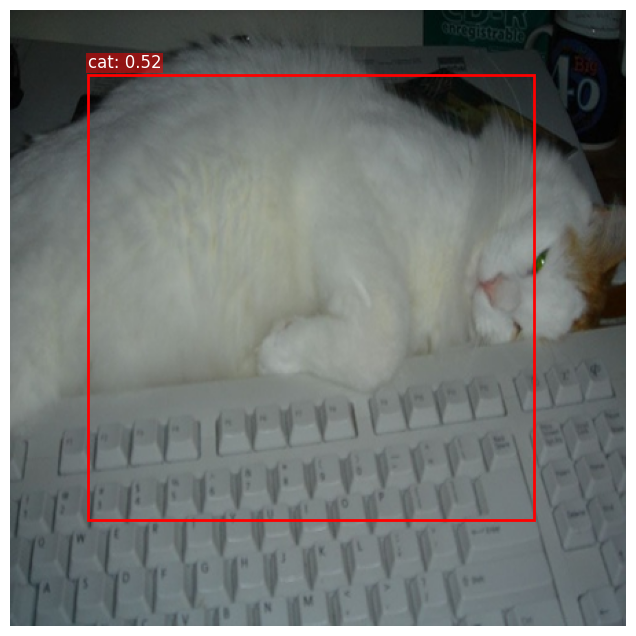

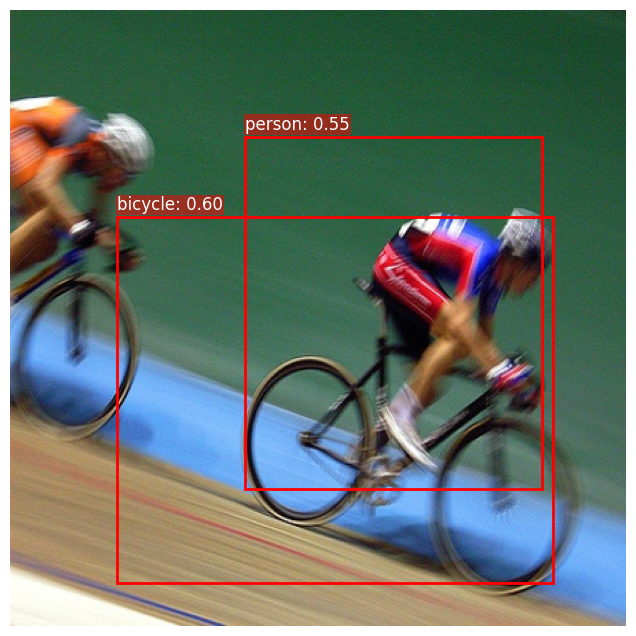

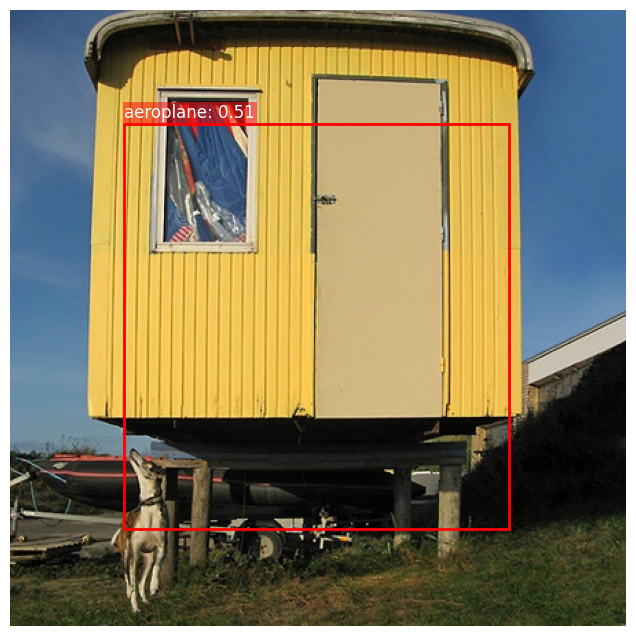

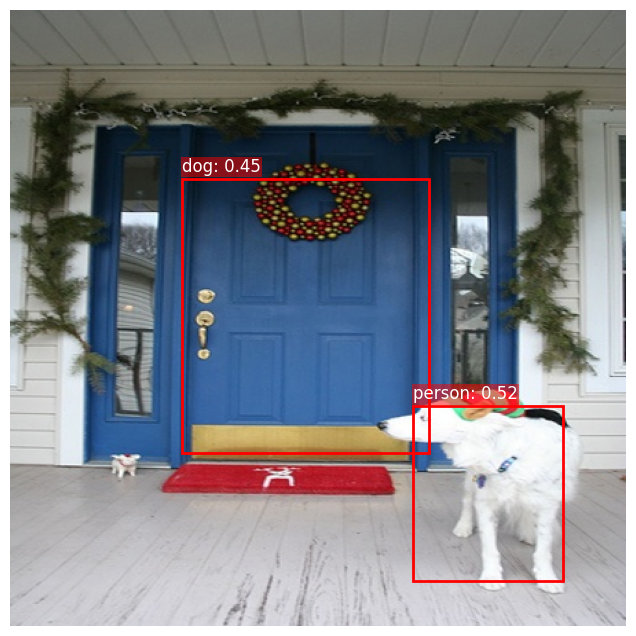

In [10]:
import random

# Chọn số lượng ảnh muốn test thử (ví dụ: 4 ảnh)
num_samples = 4
random_indices = random.sample(range(len(test_dataset)), num_samples)



for idx in random_indices:
    # 1. Lấy ảnh và nhãn thật từ tập test
    sample_image, _ = test_dataset[idx]
    
    # 2. Chạy dự đoán bằng mô hình YOLOv1 đã train
    predicted_boxes = predict_single_image(model, sample_image, device, conf_threshold=0.4)
    
    for box in predicted_boxes:
        class_id, conf = int(box[0]), box[1]
        
        
    # 3. Vẽ hình kèm bounding box lên màn hình
    visualize_prediction(sample_image, predicted_boxes, VOC_CLASSES)